In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import pairwise_distances_argmin_min

import pandas as pd
import seaborn as sns

In [3]:
(X_train,y_train), (X_test,y_test) = fashion_mnist.load_data()
X_train.shape[1]

28

In [8]:
X = X_train.reshape(-1,X_train.shape[1]*X_train.shape[2])
X.shape


(60000, 784)

In [9]:
y=y_train
y.shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Unique classes:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))
class_counts = pd.Series(y_train).value_counts().sort_index()

print(class_counts)



Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


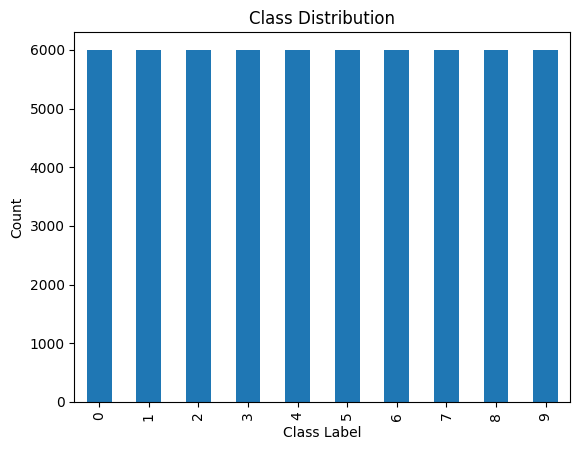

In [6]:
plt.figure()

class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

##  Dataset Class Mapping
The Fashion MNIST dataset contains 10 categories represented by integer labels (0-9). In this section, we define a mapping for these labels and visualize the **"canonical"** or first instance of each class to establish a baseline for our classification task.

* **Goal:** Verify data integrity and understand the visual characteristics of each garment type.
* **Categories:** T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.

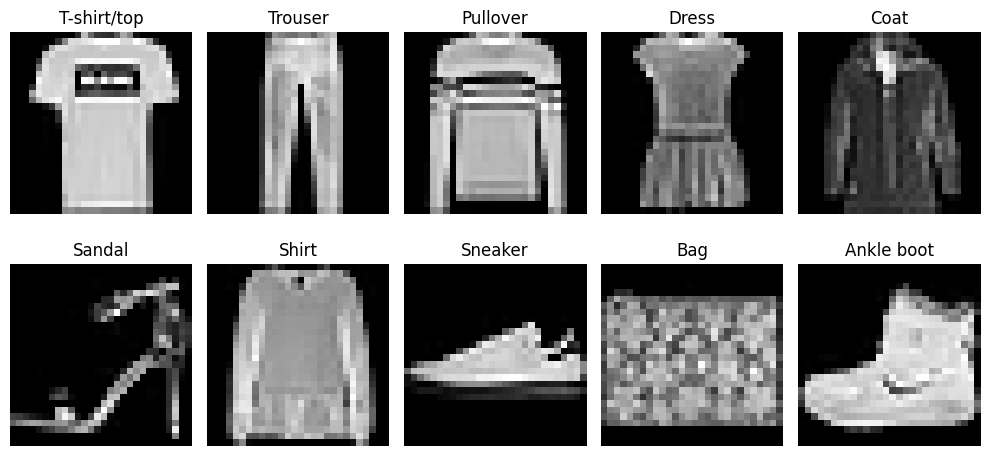

In [7]:
label_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
plt.figure(figsize=(10,5))

for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(label_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Qualitative Data Inspection (Random Sampling)
To understand the complexity and **intra-class variance** (differences within the same category), we visualize 25 random samples from the training set. 

This helps identify potential challenges for our clustering algorithm, such as:
1. **Silhouette Similarity:** "Shirts" and "Coats" sharing similar outlines.
2. **Orientation:** Items facing different directions.
3. **Style Variance:** Differences between high-top sneakers and low-cut sneakers.

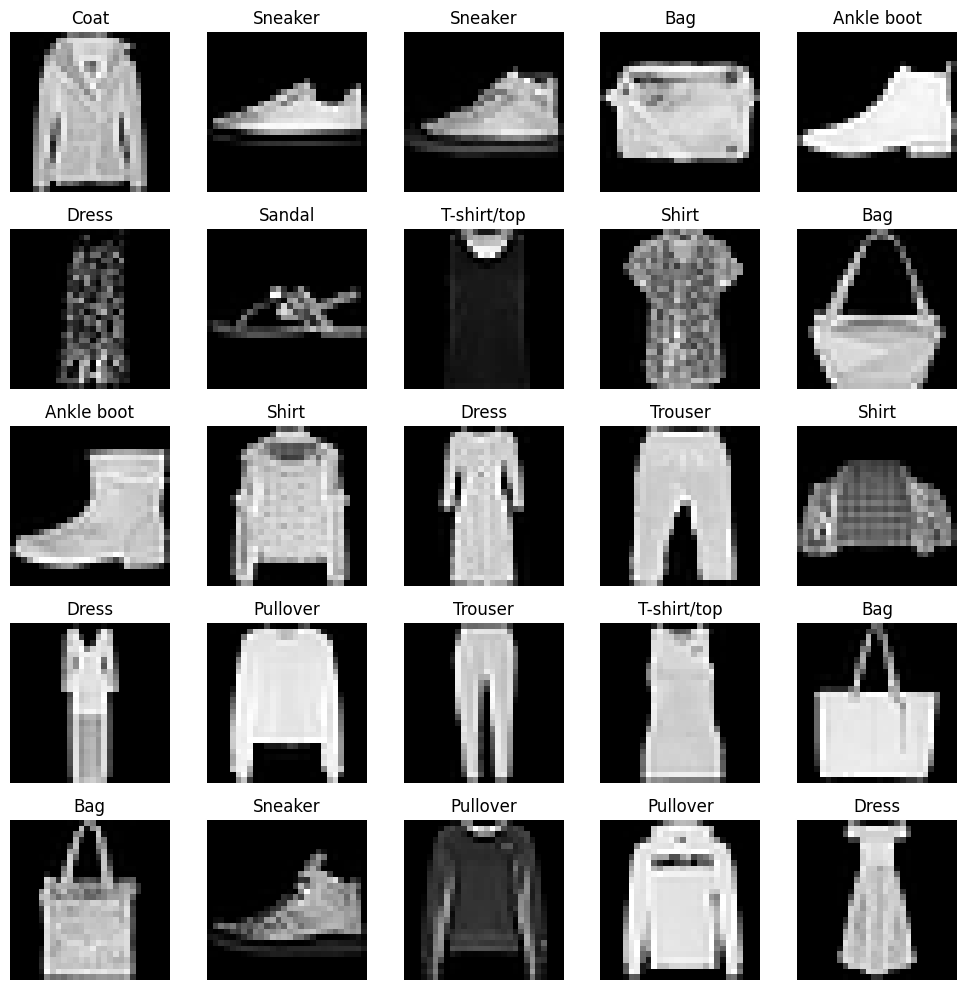

In [32]:
plt.figure(figsize=(10,10))

indices = np.random.choice(len(X_train), 25, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(label_names[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Pixel Intensity Distribution
Before feeding the data into a Multi-Layer Perceptron (MLP) or K-Means clustering, we must analyze the distribution of pixel values. 

**Observations:**
* **Bimodal Distribution:** A massive spike at `0` represents the black background, while the spread toward `255` represents the garment textures.
* **Normalization Requirement:** Since most values are at the extremes, feature scaling (dividing by 255) is essential. This ensures that the weights in our MLP don't explode and that the Euclidean distance in K-Means isn't biased by large raw pixel values.

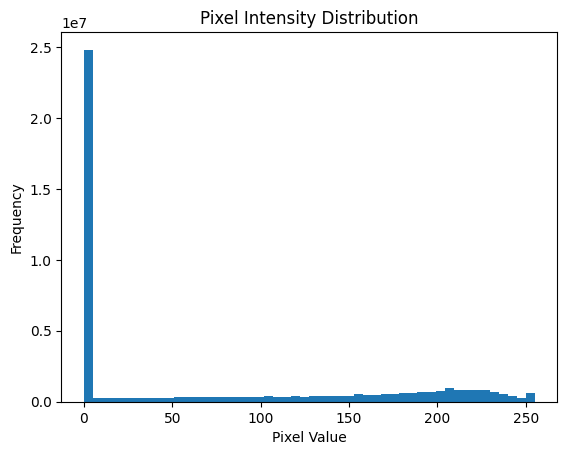

In [33]:
plt.figure()
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

## Class Prototypes (Mean Image Analysis)
We compute the **average image** for each of the 10 categories. This visualization provides insight into the "global shape" that defines each garment type.

**Key Insights for Semi-Supervised Learning:**
* **Cluster Stability:** Categories with very sharp mean images (like "Trouser") are likely to form very tight, accurate clusters in K-Means.
* **Ambiguity:** Categories with "fuzzier" mean images (like "Shirt") indicate high variability, which explains why the K-Means algorithm might misclassify these samples during label propagation.
* **Feature Engineering:** These mean images represent the "ideal" features the MLP should prioritize when distinguishing between similar classes like Pullovers and Coats.

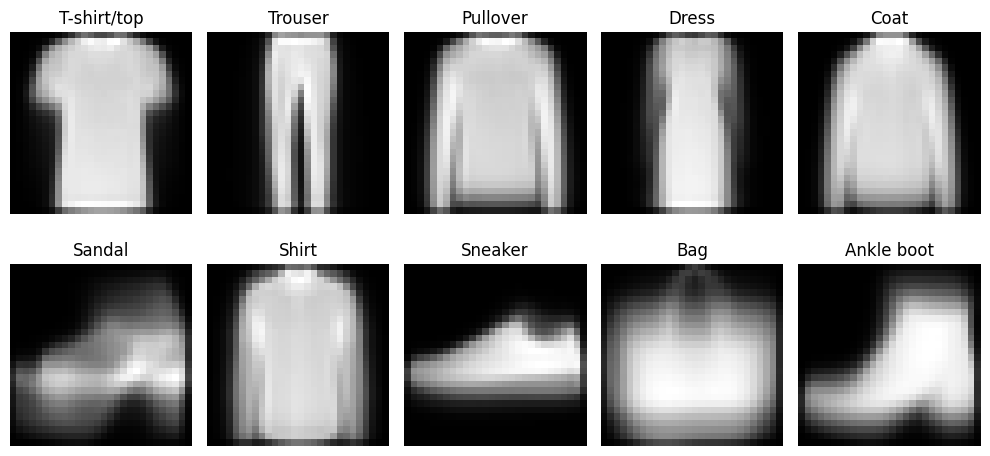

In [34]:
plt.figure(figsize=(10,5))

for i in range(10):
    class_images = X_train[y_train == i]
    mean_image = np.mean(class_images, axis=0)

    plt.subplot(2,5,i+1)
    plt.imshow(mean_image, cmap='gray')
    plt.title(label_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Image Variance Distribution
This visualization helps us understand the "richness" of the features in our dataset. High variance images contain a mix of very dark and very light pixels (high contrast), while low variance images indicate simpler, more uniform designs.


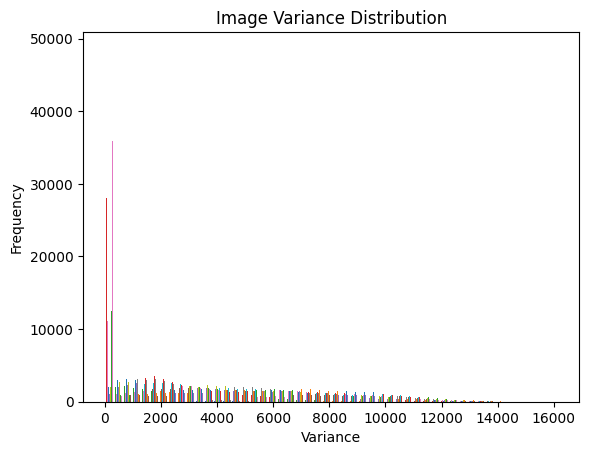

In [35]:
variances = np.var(X_train, axis=1)

plt.figure()
plt.hist(variances, bins=50)
plt.title("Image Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.show()

## PCA Projection: Visualizing Cluster Separation
To evaluate how easily the Fashion MNIST classes can be separated by a linear clustering algorithm like K-Means, we use **Principal Component Analysis (PCA)** to project the 784-dimensional pixel data into a 2D plane. Even in just 2 dimensions, we can see distinct "islands" of color. This confirms that visual similarity correlates strongly with class labels. Areas where colors mix (typically Shirts, Coats, and Pullovers) represent the "High-Entropy" regions where our label propagation is most likely to make errors.The existence of these groupings justifies using K-Means to find representative "seed" labels. If the plot were a random cloud of mixed colors, semi-supervised learning would not be effective.

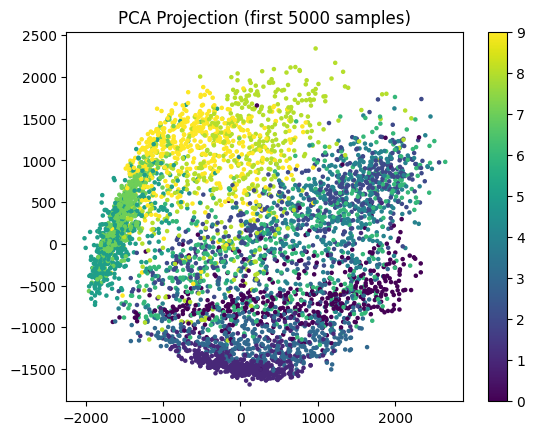

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_sample = X[:5000]
y_sample = y[:5000]

X_pca = pca.fit_transform(X_sample)

plt.figure()
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_sample, s=5)
plt.title("PCA Projection (first 5000 samples)")
plt.colorbar(scatter)
plt.show()

## Preparing the data
To prepare the image data for machine learning algorithms (K-Means and MLP), we must transform the 2D pixel grids into 1D feature vectors and scale the numerical range. We reshape the $28 \times 28$ tensors into $784$-dimensional vectors. This is necessary because standard K-Means and Scikit-Learn MLP implementations expect a 2D array input of shape `(n_samples, n_features)`. We divide the pixel values by $255.0$. 
   *  Raw pixel values ($0$ to $255$) can cause gradient explosion in MLPs and biased Euclidean distances in K-Means. 
   *  Scaling to the $[0, 1]$ range ensures faster convergence and more stable training for the Multi-Layer Perceptron.

In [14]:
X_images = X_train                      # (60000, 28, 28)
X_flat = X_train.reshape(-1, 784)       # (60000, 784)
y = y_train
X_flat = X_flat / 255.0  #normalizing 

##  Semi-Supervised Learning Experiment
Following the methodology from Lecture 14, we perform semi-supervised learning by clustering the dataset and identifying representative samples. 

### Why $K > 10$?
While there are 10 classes, using $K=20, 50, 100$ allows the algorithm to capture **intra-class variance** (different styles of the same garment). This ensures the "representative" image for a cluster is a cleaner signal for the Multi-Layer Perceptron (MLP).

In [20]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier

# 1. Preparation
X_scaled = X_train.reshape(-1, 784) / 255.0
X_test_flat = X_test.reshape(-1, 784) / 255.0

# Define range from 10 to 100 with steps of 10
k_range = range(10, 101, 10)
sweep_results = []

print(f"Starting sweep for K values: {list(k_range)}")

for k in k_range:
    start_time = time.time()
    
    # Clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5) # Reduced n_init for speed in sweep
    X_dist = kmeans.fit_transform(X_scaled)
    
    # Representative Seeds
    representative_idx = np.argmin(X_dist, axis=0)
    y_rep = y_train[representative_idx]
    
    # Partial Propagation (Top 20%)
    y_propagated = np.full(len(X_scaled), -1, dtype=np.int32)
    for i in range(k):
        cluster_indices = (kmeans.labels_ == i)
        dist_to_centroid = X_dist[cluster_indices, i]
        cutoff = np.percentile(dist_to_centroid, 20)
        
        mask = (cluster_indices) & (X_dist[:, i] <= cutoff)
        y_propagated[mask] = y_rep[i]

    # Filter and Train
    train_mask = (y_propagated != -1)
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=400, random_state=42)
    mlp.fit(X_scaled[train_mask], y_propagated[train_mask])
    
    # Score
    acc = mlp.score(X_test_flat, y_test)
    sweep_results.append({"K": k, "Accuracy": acc, "Time": time.time() - start_time})
    
    print(f"Done: K={k} | Accuracy: {acc:.4f}")

df_sweep = pd.DataFrame(sweep_results)

Starting sweep for K values: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Done: K=10 | Accuracy: 0.4612
Done: K=20 | Accuracy: 0.5904
Done: K=30 | Accuracy: 0.5911
Done: K=40 | Accuracy: 0.6115
Done: K=50 | Accuracy: 0.6289
Done: K=60 | Accuracy: 0.6292
Done: K=70 | Accuracy: 0.6500
Done: K=80 | Accuracy: 0.6790
Done: K=90 | Accuracy: 0.6828
Done: K=100 | Accuracy: 0.7122


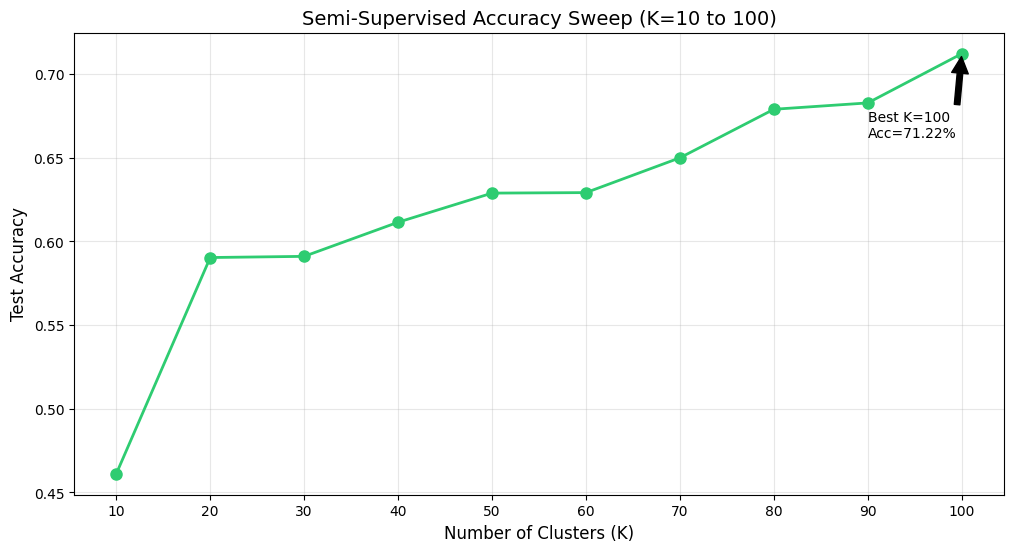

,K,Accuracy,Time
0,10,0.4612,89.416286
1,20,0.5904,152.997485
2,30,0.5911,151.589142
3,40,0.6115,165.406403
4,50,0.6289,243.751568
5,60,0.6292,171.604643
6,70,0.6500,125.073149
7,80,0.6790,288.876385
8,90,0.6828,236.436365
9,100,0.7122,186.128349


In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df_sweep['K'], df_sweep['Accuracy'], 'o-', color='#2ecc71', linewidth=2, markersize=8)

# Highlight the best K
best_row = df_sweep.loc[df_sweep['Accuracy'].idxmax()]
plt.annotate(f"Best K={int(best_row['K'])}\nAcc={best_row['Accuracy']:.2%}", 
             xy=(best_row['K'], best_row['Accuracy']), 
             xytext=(best_row['K']-10, best_row['Accuracy']-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Semi-Supervised Accuracy Sweep (K=10 to 100)", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

display(df_sweep)

Calculating validation metrics...
K=10 | Silhouette Score: 0.1567
K=20 | Silhouette Score: 0.1107
K=30 | Silhouette Score: 0.0950
K=40 | Silhouette Score: 0.0851
K=50 | Silhouette Score: 0.0762
K=60 | Silhouette Score: 0.0727
K=70 | Silhouette Score: 0.0704
K=80 | Silhouette Score: 0.0681
K=90 | Silhouette Score: 0.0647
K=100 | Silhouette Score: 0.0646


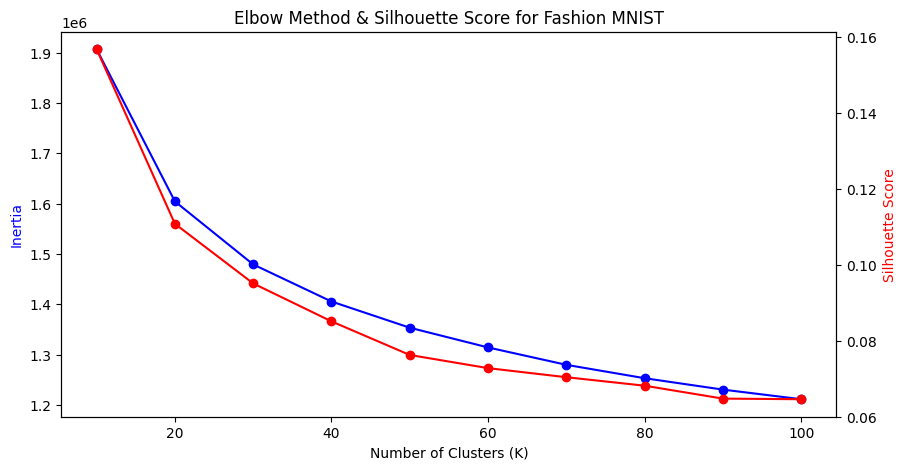

In [ ]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_avgs = []
k_test_range = range(10, 101, 10) # Testing 10, 30, 50, 70, 90


for k in k_test_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(X_scaled)
    
    # 1. Inertia for Elbow Method
    inertias.append(km.inertia_)
    
    # 2. Silhouette Score (calculated on a sample for speed)
    sample_idx = np.random.choice(len(X_scaled), 10000, replace=False)
    score = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    silhouette_avgs.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

# Plotting the validation
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_test_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(k_test_range, silhouette_avgs, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title("Elbow Method & Silhouette Score for Fashion MNIST")
plt.show()

In [35]:
from kneed import KneeLocator

# 1. Programmatically find the "Elbow" in the Inertia curve
kn = KneeLocator(k_test_range, inertias, curve='convex', direction='decreasing')
best_k = kn.knee

if best_k is None:
    best_k = 50 # Fallback if curve is too linear

# 2. Select neighbors around the elbow
neighbors = [best_k - 10, best_k, best_k + 10]
neighbors = [k for k in neighbors if 10 <= k <= 100]

print(f"Mathematical Optimum K (Elbow Point): {best_k}")
print(f"Refinement Range: {neighbors}")

Mathematical Optimum K (Elbow Point): 30
Refinement Range: [np.int64(20), np.int64(30), np.int64(40)]


In [ ]:
refinement_results = []

for k in neighbors:
    
    # --- Step A: Clustering ---
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_dist = km.fit_transform(X_scaled)
    
    # --- Step B: Representative Seeds ---
    rep_idx = np.argmin(X_dist, axis=0)
    y_rep = y_train[rep_idx]
    
    # --- Step C: Partial Propagation (Top 20%) ---
    y_prop = np.full(len(X_scaled), -1, dtype=np.int32)
    for i in range(k):
        cluster_mask = (km.labels_ == i)
        dist_to_centroid = X_dist[cluster_mask, i]
        cutoff = np.percentile(dist_to_centroid, 20)
        
        prop_mask = (cluster_mask) & (X_dist[:, i] <= cutoff)
        y_prop[prop_mask] = y_rep[i]

    # --- Step D: Train MLP ---
    train_mask = (y_prop != -1)
    mlp_final = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
    mlp_final.fit(X_scaled[train_mask], y_prop[train_mask])
    
    # --- Step E: Score ---
    acc = mlp_final.score(X_test_flat, y_test)
    refinement_results.append({"K": k, "Test Accuracy": acc, "Samples Used": sum(train_mask)})

# Display the Comparison
df_refine = pd.DataFrame(refinement_results)
display(df_refine)

Processing K=10...
Processing K=20...


,K,Test Accuracy,Samples Used
0,10,0.4612,12004
1,20,0.5816,12008


valid mlp k=30 and nbd


In [37]:
import pandas as pd

# The neighbors identified by the KneeLocator
final_neighbors = [20, 30, 40]
refinement_data = []


for k in final_neighbors:
    # 1. Clustering
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_dist = km.fit_transform(X_scaled)
    
    # 2. Representative Selection
    rep_idx = np.argmin(X_dist, axis=0)
    y_rep = y_train[rep_idx]
    
    # 3. Partial Propagation (20% Threshold)
    y_prop = np.full(len(X_scaled), -1, dtype=np.int32)
    for i in range(k):
        mask = (km.labels_ == i)
        dist_to_centroid = X_dist[mask, i]
        cutoff = np.percentile(dist_to_centroid, 20)
        y_prop[(mask) & (X_dist[:, i] <= cutoff)] = y_rep[i]

    # 4. Filter and Train MLP
    train_mask = (y_prop != -1)
    mlp_final = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
    mlp_final.fit(X_scaled[train_mask], y_prop[train_mask])
    
    # 5. Evaluate on Test Set
    accuracy = mlp_final.score(X_test_flat, y_test)
    refinement_data.append({"K": k, "Accuracy": accuracy, "Images Labeled": sum(train_mask)})

# Display results in a neat table
df_final_comparison = pd.DataFrame(refinement_data)
display(df_final_comparison)

,K,Accuracy,Images Labeled
0,20,0.5816,12008
1,30,0.5911,12013
2,40,0.6111,12017


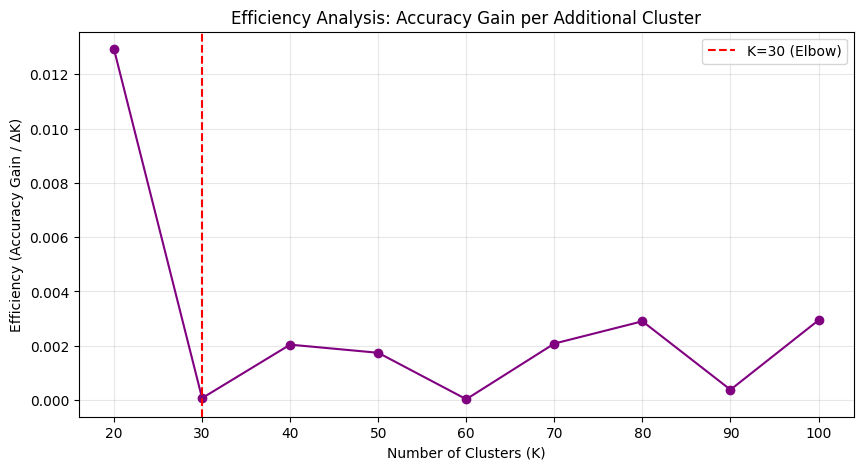

Efficiency at K=30: 0.0001
Efficiency at K=100: 0.0029


In [40]:
# Calculate the "Return on Investment" for labeling more clusters
df_sweep['Acc_Gain_Per_K'] = df_sweep['Accuracy'].diff() / df_sweep['K'].diff()

plt.figure(figsize=(10, 5))
plt.plot(df_sweep['K'], df_sweep['Acc_Gain_Per_K'], 'o-', color='purple')
plt.axvline(x=30, color='r', linestyle='--', label='K=30 (Elbow)')
plt.title("Efficiency Analysis: Accuracy Gain per Additional Cluster")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Efficiency (Accuracy Gain / ΔK)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Efficiency at K=30: {df_sweep.loc[df_sweep['K']==30, 'Acc_Gain_Per_K'].values[0]:.4f}")
print(f"Efficiency at K=100: {df_sweep.loc[df_sweep['K']==100, 'Acc_Gain_Per_K'].values[0]:.4f}")

In [41]:
# Create an Efficiency Table
df_efficiency = df_sweep.copy()
df_efficiency['Gain_per_Label'] = df_efficiency['Accuracy'].diff() / df_efficiency['K'].diff()

print("Efficiency Table (Accuracy gain per additional label):")
display(df_efficiency[['K', 'Accuracy', 'Gain_per_Label']].fillna(0))

# Identify the point where efficiency drops below a threshold (e.g., 0.001)
diminishing_point = df_efficiency[df_efficiency['Gain_per_Label'] < 0.001]['K'].min()
print(f"\nDiminishing returns begin at K = {diminishing_point}")

Efficiency Table (Accuracy gain per additional label):


,K,Accuracy,Gain_per_Label
0,10,0.4612,0.00000
1,20,0.5904,0.01292
2,30,0.5911,0.00007
3,40,0.6115,0.00204
4,50,0.6289,0.00174
5,60,0.6292,0.00003
6,70,0.6500,0.00208
7,80,0.6790,0.00290
8,90,0.6828,0.00038
9,100,0.7122,0.00294



Diminishing returns begin at K = 30


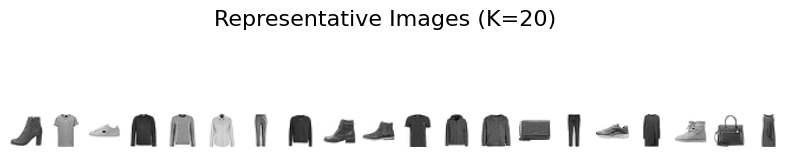

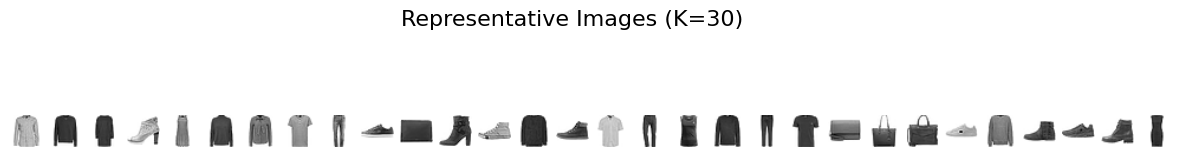

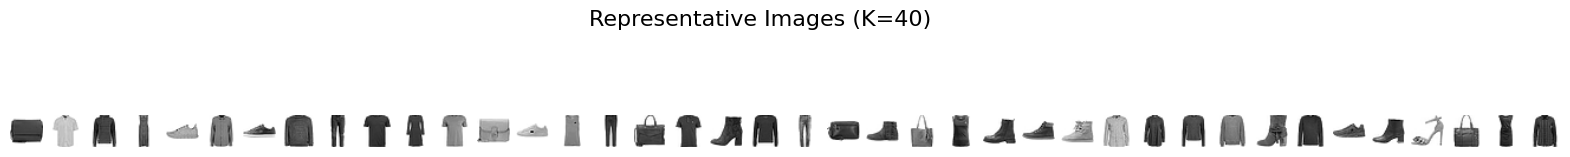

In [42]:
def plot_representative_images(k_val, X_data, y_labels, title):
    # 1. Run K-Means
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=5)
    X_dist = kmeans.fit_transform(X_data)
    
    # 2. Find indices of images closest to centroids
    representative_idx = np.argmin(X_dist, axis=0)
    X_rep = X_data[representative_idx]
    y_rep = y_labels[representative_idx]
    
    # 3. Plotting logic
    plt.figure(figsize=(k_val/2, 2))
    for index, image_data in enumerate(X_rep):
        plt.subplot(1, k_val, index + 1)
        # Reshape back to 28x28 for display
        plt.imshow(image_data.reshape(28, 28), cmap="binary", interpolation="bilinear")
        plt.axis('off')
    plt.suptitle(f"{title} (K={k_val})", fontsize=16, y=1.1)
    plt.show()

# Execute for your three target K values
for k in [20, 30, 40]:
    plot_representative_images(k, X_scaled, y_train, "Representative Images")

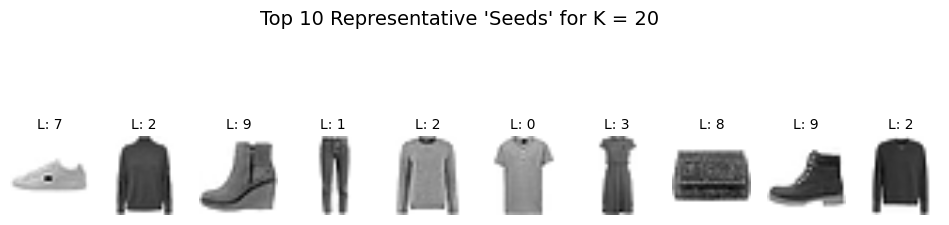

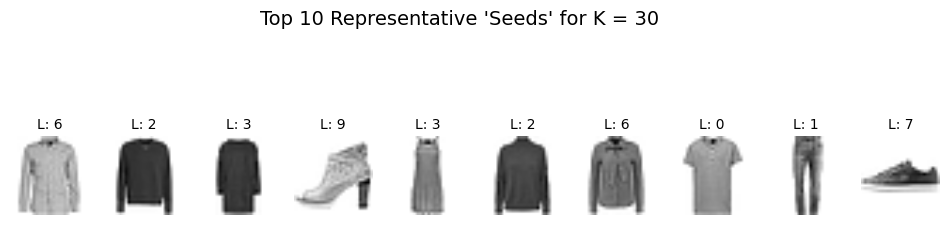

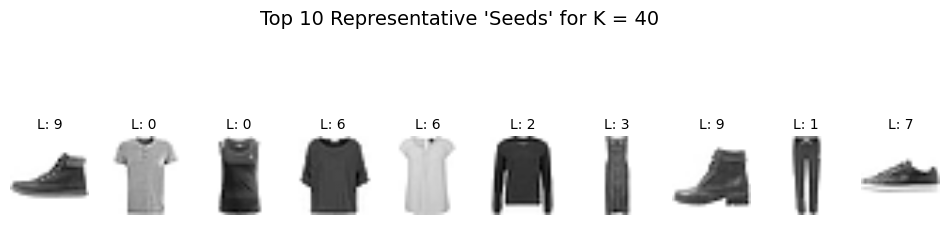

In [43]:
import matplotlib.pyplot as plt

# The specific K values we identified as the optimum neighborhood
k_comparison = [20, 30, 40]

for k in k_comparison:
    # 1. Run K-Means for the specific K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_digits_dist = kmeans.fit_transform(X_scaled) # Using X_scaled from previous steps

    # 2. Find images closest to centroids (the 'seeds')
    representative_idx = np.argmin(X_digits_dist, axis=0)
    X_representative = X_scaled[representative_idx]
    y_representative = y_train[representative_idx]

    # 3. Visualize the first 10 Representative Images for this K
    plt.figure(figsize=(12, 3))
    for index, img in enumerate(X_representative[:10]): # Showing first 10 for brevity
        plt.subplot(1, 10, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="binary", interpolation="bilinear")
        plt.title(f"L: {y_representative[index]}", fontsize=10)
        plt.axis("off")
    
    plt.suptitle(f"Top 10 Representative 'Seeds' for K = {k}", fontsize=14, y=1.05)
    plt.show()

Baseline Accuracy (30 Random Samples): 58.10%
Semi-Supervised Accuracy (K=30 Seeds): 59.11%
Performance Boost: 1.01%


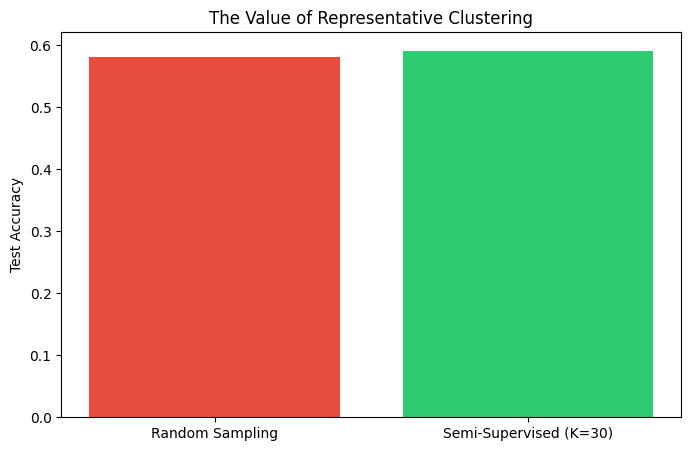

In [44]:
# 1. Select 30 random indices from the training set
np.random.seed(42)
random_indices = np.random.choice(len(X_scaled), 30, replace=False)
X_random_sample = X_scaled[random_indices]
y_random_sample = y_train[random_indices]

# 2. Train a baseline MLP on these 30 random images
mlp_random = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
mlp_random.fit(X_random_sample, y_random_sample)
random_acc = mlp_random.score(X_test_flat, y_test)

# 3. Retrieve your K=30 accuracy from your previous sweep
k30_acc = df_sweep.loc[df_sweep['K'] == 30, 'Accuracy'].values[0]

print(f"Baseline Accuracy (30 Random Samples): {random_acc:.2%}")
print(f"Semi-Supervised Accuracy (K=30 Seeds): {k30_acc:.2%}")
print(f"Performance Boost: {k30_acc - random_acc:.2%}")

# Visualization of the Comparison
plt.figure(figsize=(8, 5))
plt.bar(['Random Sampling', 'Semi-Supervised (K=30)'], [random_acc, k30_acc], color=['#e74c3c', '#2ecc71'])
plt.ylabel("Test Accuracy")
plt.title("The Value of Representative Clustering")
plt.show()

In [45]:
# 1. Select 30 random images from the training set
np.random.seed(42)
random_indices = np.random.choice(len(X_scaled), 30, replace=False)
X_random_sample = X_scaled[random_indices]
y_random_sample = y_train[random_indices]

# 2. Train a baseline MLP on these 30 random images
mlp_random = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
mlp_random.fit(X_random_sample, y_random_sample)
random_acc = mlp_random.score(X_test_flat, y_test)

# 3. Compare with your K=30 accuracy
k30_acc = df_sweep.loc[df_sweep['K'] == 30, 'Accuracy'].values[0]

print(f"Baseline Accuracy (30 Random Samples): {random_acc:.2%}")
print(f"Semi-Supervised Accuracy (K=30): {k30_acc:.2%}")
print(f"Performance Boost from Clustering: {k30_acc - random_acc:.2%}")

Baseline Accuracy (30 Random Samples): 58.10%
Semi-Supervised Accuracy (K=30): 59.11%
Performance Boost from Clustering: 1.01%
